<a href="https://colab.research.google.com/github/towardsai/ai-tutor-rag-system/blob/main/notebooks/Multimodal_LLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal LLMs: Seeing, Retrieving, and Locating

So far our pipeline reads *text*. But the flagship models from all three of our providers accept **images natively** — and most real document collections are full of screenshots, figures, scans, and photos that a text-only pipeline silently ignores.

In this notebook we make images first-class citizens of the same RAG pattern you already know. We build a tiny visual archive, let a vision model **describe** each image, **embed** those descriptions with the course's `embed()` helper, and retrieve images by meaning — then finish with the most production-relevant vision trick of all: **object detection returned as schema-validated JSON**.

📎 *Same `generate()`/`embed()` helpers, same chunk → embed → search → answer skeleton from the Basic RAG notebook — we are extending the pipeline's reach, not replacing it.*

## 🧭 What You'll Learn

- `generate_vision()`: one helper that sends an **image + prompt** to any of the three providers
- The **describe → embed → search** pattern: multimodal retrieval powered by ordinary text embeddings
- Why description quality *is* retrieval quality — and how to write a description prompt worth indexing
- Mini multimodal RAG: answering questions **grounded in the retrieved image**
- **Object detection with structured outputs**: Pydantic-validated bounding boxes from Gemini's spatial understanding

## 1. Setup: Environment, Keys, and Providers

The standard course setup cell. One extra requirement in this notebook: `GOOGLE_API_KEY` is always needed, whichever chat provider you pick — the object-detection finale (Section 7) uses Gemini's spatial understanding, which is a documented strength of that model family.

The **model field is an editable dropdown** (`{allow-input: true}`): pick one of the listed course defaults, or type any newer model ID straight into the box — no code changes needed. (Locally, simply edit the string.)

In [1]:
# ============================================================
# ⚙️ Setup — environment, dependencies, API keys, provider
# ============================================================
import os
import sys

IN_COLAB = "google.colab" in sys.modules

# Pick your model providers (dropdowns in Colab; edit the values locally)
PROVIDER = "gemini"  # @param ["gemini", "openai", "anthropic"]
EMBED_PROVIDER = "gemini"  # @param ["gemini", "openai"]  (Anthropic has no embedding API)

# Pick a model for the selected provider — or TYPE any newer model ID into the
# box (the dropdown is editable thanks to allow-input):
CHAT_MODEL = "gemini-3.7-flash"  # @param ["gemini-3.7-flash", "gemini-3.5-flash-lite", "gpt-5.6-luna", "claude-sonnet-5"] {allow-input: true}
EMBED_MODEL = "gemini-embedding-001"  # @param ["gemini-embedding-001", "text-embedding-3-small"] {allow-input: true}

_KEY_FOR = {"gemini": "GOOGLE_API_KEY", "openai": "OPENAI_API_KEY", "anthropic": "ANTHROPIC_API_KEY"}
REQUIRED_KEYS = sorted({_KEY_FOR[PROVIDER], _KEY_FOR[EMBED_PROVIDER]} | {"GOOGLE_API_KEY"})  # Gemini is always required here: Section 7's detection demo uses Gemini spatial understanding

if IN_COLAB:
    import importlib
    import site
    import subprocess

    # Shared install profile, pinned course-wide (July 2026).
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q", "-U",
            "google-genai==2.3.0",
            "openai==2.46.0",
            "anthropic==0.117.0",
        ],
        check=True,
    )
    importlib.reload(site)  # make newly installed packages importable without a runtime restart

    # In Colab: Secrets tab (🔑 icon) → Add new secret → e.g. GOOGLE_API_KEY
    from google.colab import userdata

    for key in REQUIRED_KEYS:
        os.environ[key] = userdata.get(key)

if not IN_COLAB:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")

    # Locally: dependencies are installed once from the repo's requirements.
    # Keys live in a .env file at the repo root.
    from dotenv import load_dotenv

    load_dotenv()
    missing = [k for k in REQUIRED_KEYS if not os.getenv(k)]
    assert not missing, f"Missing from .env: {missing}"

print(f"✅ Setup complete — {'Colab' if IN_COLAB else 'local'} | chat: {PROVIDER} | embeddings: {EMBED_PROVIDER}")

✅ Setup complete — local | chat: gemini | embeddings: gemini


## 2. The Course Helpers, Plus a New One: `generate_vision()`

`generate()` and `embed()` are unchanged. The new arrival is `generate_vision()` — the same idea as `generate()`, but the prompt travels *with an image*. All three provider SDKs accept images as content parts; only the packaging differs, so we hide it behind one function and the rest of the notebook stays provider-neutral.

In [2]:
# 📎 generate() and embed() are the course's two provider helpers,
#    built in “How To Use LLMs via API” and “Basic RAG” — unchanged here.
from anthropic import Anthropic
from google import genai
from google.genai import types as genai_types
from openai import OpenAI

# Course-standard default models per provider (August 2026)
MODELS = {
    "gemini": "gemini-3.7-flash",
    "openai": "gpt-5.6-luna",
    "anthropic": "claude-sonnet-5",
}

# The setup-cell form selection (or any typed model ID) overrides the default:
MODELS[PROVIDER] = CHAT_MODEL
EMBED_MODELS = {
    "gemini": "gemini-embedding-001",
    "openai": "text-embedding-3-small",
}
EMBED_MODELS[EMBED_PROVIDER] = EMBED_MODEL  # setup-cell selection (or typed ID) wins
EMBED_DIM = 1536  # same output size for both providers, so the rest of the code never cares

# Create only the clients we actually need
if "gemini" in (PROVIDER, EMBED_PROVIDER):
    gemini_client = genai.Client()
if "openai" in (PROVIDER, EMBED_PROVIDER):
    openai_client = OpenAI()
if PROVIDER == "anthropic":
    anthropic_client = Anthropic()


def generate(prompt, system=None, model=None):
    """Send one prompt to the selected PROVIDER and return the reply text."""
    if PROVIDER == "gemini":
        response = gemini_client.models.generate_content(
            model=model or MODELS["gemini"],
            contents=prompt,
            config=genai_types.GenerateContentConfig(system_instruction=system),
        )
        return response.text

    if PROVIDER == "openai":
        response = openai_client.responses.create(
            model=model or MODELS["openai"],
            instructions=system,
            input=prompt,
            reasoning={"effort": "none"},
        )
        return response.output_text

    if PROVIDER == "anthropic":
        response = anthropic_client.messages.create(
            model=model or MODELS["anthropic"],
            max_tokens=4096,
            **({"system": system} if system else {}),
            messages=[{"role": "user", "content": prompt}],
        )
        return response.content[0].text

    raise ValueError(f"Unknown PROVIDER: {PROVIDER!r}")


def embed(texts, task="document"):
    """Embed a list of texts with the selected EMBED_PROVIDER.

    Returns a list of EMBED_DIM-dimensional vectors (one per input text).
    task: "document" for corpus chunks, "query" for user questions —
    Gemini embeds the two slightly differently to improve retrieval.
    """
    if isinstance(texts, str):
        texts = [texts]
    # Embedding models work best on single-line inputs
    texts = [t.replace("\n", " ") for t in texts]

    if EMBED_PROVIDER == "gemini":
        result = gemini_client.models.embed_content(
            model=EMBED_MODELS["gemini"],
            contents=texts,
            config=genai_types.EmbedContentConfig(
                task_type="RETRIEVAL_DOCUMENT" if task == "document" else "RETRIEVAL_QUERY",
                output_dimensionality=EMBED_DIM,
            ),
        )
        return [e.values for e in result.embeddings]

    if EMBED_PROVIDER == "openai":
        result = openai_client.embeddings.create(
            model=EMBED_MODELS["openai"], input=texts
        )
        return [d.embedding for d in result.data]

    raise ValueError(f"Unknown EMBED_PROVIDER: {EMBED_PROVIDER!r}")

In [3]:
import base64


def generate_vision(prompt, image_bytes, mime_type="image/jpeg", model=None):
    """Send one image + one prompt to the selected PROVIDER and return the reply text.

    Same contract as generate(), with pixels attached. Each SDK packages the
    image differently (raw bytes, base64 data-URL, or a typed content block),
    but the call shape — image part + text part — is identical everywhere.
    """
    if PROVIDER == "gemini":
        response = gemini_client.models.generate_content(
            model=model or MODELS["gemini"],
            contents=[
                genai_types.Part.from_bytes(data=image_bytes, mime_type=mime_type),
                prompt,
            ],
        )
        return response.text

    b64 = base64.b64encode(image_bytes).decode()

    if PROVIDER == "openai":
        response = openai_client.responses.create(
            model=model or MODELS["openai"],
            reasoning={"effort": "none"},
            input=[{
                "role": "user",
                "content": [
                    {"type": "input_image", "image_url": f"data:{mime_type};base64,{b64}"},
                    {"type": "input_text", "text": prompt},
                ],
            }],
        )
        return response.output_text

    if PROVIDER == "anthropic":
        response = anthropic_client.messages.create(
            model=model or MODELS["anthropic"],
            max_tokens=4096,
            messages=[{
                "role": "user",
                "content": [
                    {"type": "image", "source": {"type": "base64", "media_type": mime_type, "data": b64}},
                    {"type": "text", "text": prompt},
                ],
            }],
        )
        return response.content[0].text

    raise ValueError(f"Unknown PROVIDER: {PROVIDER!r}")

## 3. A Tiny Image Archive

Six public-domain classics from Wikimedia Commons — deliberately diverse (photographs, paintings, a woodblock print; street life, aviation, portraits) so that retrieval has real distinctions to make. Think of them as stand-ins for whatever *your* pipeline would index: product photos, chart screenshots, scanned invoices, slide figures.

The download is plain Python and **fail-soft**: if a file is unreachable, the notebook continues with the images that did arrive.

In [4]:
import io
import pathlib

import requests
from PIL import Image

# id → Wikimedia Commons filename (all public domain)
COMMONS_FILES = {
    "mulberry_street": "Mulberry Street NYC c1900 LOC 3g04637u edit.jpg",   # photo, NYC street market ~1900
    "first_flight": "First flight2.jpg",                                     # photo, Wright Flyer, 1903
    "starry_night": "Van Gogh - Starry Night - Google Art Project.jpg",      # painting, 1889
    "einstein": "Albert Einstein Head.jpg",                                  # photo portrait, 1947
    "great_wave": "Tsunami by hokusai 19th century.jpg",                     # woodblock print, ~1831
    "mona_lisa": "Mona Lisa, by Leonardo da Vinci, from C2RMF retouched.jpg",  # painting, ~1503
}

IMG_DIR = pathlib.Path("archive_images")
IMG_DIR.mkdir(exist_ok=True)

images = {}  # id → JPEG bytes (our in-memory corpus)
for image_id, commons_name in COMMONS_FILES.items():
    path = IMG_DIR / f"{image_id}.jpg"
    if not path.exists():
        url = ("https://commons.wikimedia.org/wiki/Special:FilePath/"
               + requests.utils.quote(commons_name) + "?width=640")
        try:
            resp = requests.get(url, timeout=30,
                                headers={"User-Agent": "towardsai-course-notebook/1.0"})
            resp.raise_for_status()
            # Normalize everything to JPEG so one mime type serves the whole notebook
            Image.open(io.BytesIO(resp.content)).convert("RGB").save(path, "JPEG", quality=90)
        except Exception as exc:
            print(f"⚠️ Skipping {image_id}: {exc}")
            continue
    images[image_id] = path.read_bytes()

print(f"Archive ready: {len(images)}/{len(COMMONS_FILES)} images")

Archive ready: 6/6 images


Matplotlib is building the font cache; this may take a moment.


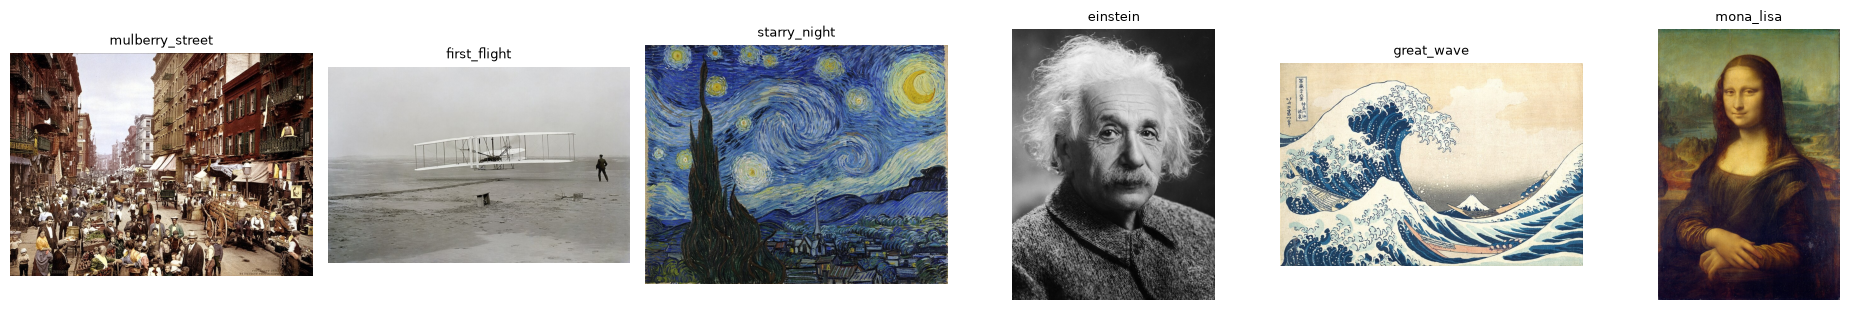

In [5]:
import matplotlib.pyplot as plt

# Always LOOK at your corpus — that rule applies to pixels too.
fig, axes = plt.subplots(1, len(images), figsize=(3.2 * len(images), 3.2))
for ax, (image_id, data) in zip(axes, images.items()):
    ax.imshow(Image.open(io.BytesIO(data)))
    ax.set_title(image_id, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

**What just happened?** Six images became our corpus, normalized to JPEG so a single MIME type serves every API call. Note the deliberate spread: two portraits (a *photograph* and a *painting*), two artworks of very different styles, two historical photos of very different subjects. Ambiguity like "portrait" vs "painting" is exactly what a good retrieval system must resolve — we test it shortly.

## 4. First Look: an LLM Reads an Image

Before building anything, verify the core capability — send one image with a question and see what comes back. This is the multimodal equivalent of our very first `generate("Hello!")` sanity check.

In [6]:
reply = generate_vision(
    "What is happening in this photograph? Answer in two sentences.",
    images["mulberry_street"],
)
print(reply)

This historical photograph captures a bustling open-air market along Mulberry Street in New York City around the turn of the 20th century. Crowds of pedestrians, street vendors, and children fill the lively street, which is lined with tall tenement buildings, produce carts, and horse-drawn wagons.


**What just happened?** The model read pixels and wrote grounded prose — no OCR step, no separate vision service, just an extra content part in the same API you have used all course (**your output may differ**). Every capable vision-language model works this way: images are encoded into the same token stream the transformer already processes. That one fact is the foundation for everything below.

## 5. Multimodal Retrieval: Describe → Embed → Search

You cannot put a JPEG into a text embedding model — but you *can* put a good **description** of it. That gives the classic, robust recipe for image retrieval:

1. **Describe** every image once with a vision model (one-time indexing cost)
2. **Embed** the descriptions with the course's ordinary `embed()` helper
3. **Search** exactly as in the Basic RAG notebook — the query and the descriptions live in the same vector space

The craft is in step 1: the description is the *only* thing retrieval ever sees. A lazy caption ("an old photo") indexes almost nothing; a dense, factual description indexes everything. Our prompt asks for subjects, medium, era, objects, and mood — the attributes people actually search by.

In [7]:
DESCRIBE_PROMPT = (
    "Describe this image for a search index. In 3-5 sentences, cover: the main "
    "subject(s) and any activities; the medium and style (photograph, oil painting, "
    "woodblock print...); the approximate era or date if inferable; notable objects, "
    "people, and text; and the overall mood. Be dense and factual — every sentence "
    "should add searchable information. Do not start with 'This image shows'."
)

descriptions = {}
for image_id, data in images.items():
    descriptions[image_id] = generate_vision(DESCRIBE_PROMPT, data)
    print(f"✅ described {image_id}")

print("\nSample description (mulberry_street):\n")
print(descriptions["mulberry_street"])

✅ described mulberry_street


✅ described first_flight


✅ described starry_night


✅ described einstein


✅ described great_wave


✅ described mona_lisa

Sample description (mulberry_street):

A bustling street market scene on Mulberry Street in New York City around 1900 captures Italian immigrant residents, pedestrians, and street vendors selling fresh produce from wooden handcarts between towering multi-story tenement buildings fitted with fire escapes. Rendered as a vintage colorized photochrom print by the Detroit Photographic Co., the scene features horse-drawn wagons, striped awnings, street lanterns, and storefront signage including "BANCA MALZONE." Visible text in the lower margins includes "MULBERRY STREET, NEW YORK CITY" and "COPYRIGHT 1900, BY DETROIT PHOTOGRAPHIC CO." The diverse crowd includes men in bowler hats and waistcoats, women in traditional shawls and aprons, and numerous barefoot or cap-wearing children, creating a lively, chaotic, and historic atmosphere of turn-of-the-century immigrant life in Manhattan.


In [8]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 📎 Same embed() and cosine-similarity search as the Basic RAG notebook —
#    the only new idea is WHAT we embed: descriptions standing in for images.
image_ids = list(descriptions)
desc_matrix = np.array(embed([descriptions[i] for i in image_ids], task="document"))


def search_images(query, top_k=3):
    """Return the top_k images whose descriptions best match the query."""
    q = np.array(embed(query, task="query")[0])
    scores = cosine_similarity([q], desc_matrix)[0]
    ranked = np.argsort(scores)[::-1][:top_k]
    return [(image_ids[i], float(scores[i])) for i in ranked]


print(f"Indexed {len(image_ids)} images at {desc_matrix.shape[1]} dimensions")

Indexed 6 images at 1536 dimensions


In [9]:
QUERIES = [
    "a crowded city street market with horse-drawn carts",
    "a painting of a swirling night sky over a village",
    "the first powered airplane taking off",
    "a famous portrait of a woman",   # must prefer the painting over the Einstein photo
]

for query in QUERIES:
    results = search_images(query)
    print(f"query: {query!r}")
    for rank, (image_id, score) in enumerate(results, start=1):
        marker = "◀" if rank == 1 else " "
        print(f"   {rank}. {image_id:16s} {score:.4f} {marker}")
    print()

query: 'a crowded city street market with horse-drawn carts'
   1. mulberry_street  0.7396 ◀
   2. starry_night     0.5535  
   3. first_flight     0.5436  



query: 'a painting of a swirling night sky over a village'
   1. starry_night     0.7507 ◀
   2. great_wave       0.6069  
   3. mona_lisa        0.5912  



query: 'the first powered airplane taking off'
   1. first_flight     0.7294 ◀
   2. einstein         0.5163  
   3. great_wave       0.5157  



query: 'a famous portrait of a woman'
   1. mona_lisa        0.7031 ◀
   2. einstein         0.6383  
   3. starry_night     0.6086  



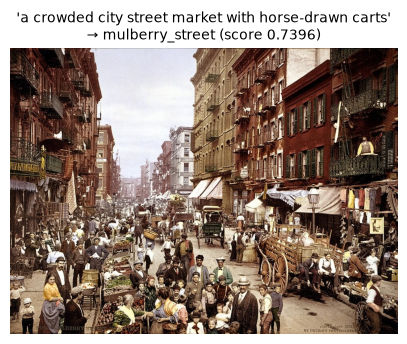

In [10]:
# Show the winning image for one query, with its score — always inspect retrieval.
query = QUERIES[0]
best_id, best_score = search_images(query, top_k=1)[0]

plt.figure(figsize=(5, 5))
plt.imshow(Image.open(io.BytesIO(images[best_id])))
plt.title(f"{query!r}\n→ {best_id} (score {best_score:.4f})", fontsize=10)
plt.axis("off")
plt.show()

**What just happened?** Ordinary *text* embeddings just retrieved *images* — because the descriptions carried the visual semantics across the modality gap. Check the fourth query: "a famous portrait of a woman" had to out-rank Einstein (a portrait, but a photograph of a man) with the Mona Lisa, and the medium/subject details in the descriptions are what made that distinction possible. The corollary is the section's real lesson: **retrieval quality is capped by description quality.** Garbage captions in, garbage retrieval out.

In [11]:
# 🔬 OPTIONAL EXPERIMENT — prove that description quality IS retrieval quality.
# Re-index with deliberately lazy one-line captions and watch the rankings degrade
# (scores flatten, and the portrait query usually stops distinguishing).
LAZY_PROMPT = "Caption this image in at most six words."

lazy_desc = {i: generate_vision(LAZY_PROMPT, d) for i, d in images.items()}
lazy_matrix = np.array(embed([lazy_desc[i] for i in image_ids], task="document"))

q = np.array(embed("a famous portrait of a woman", task="query")[0])
scores_rich = cosine_similarity([q], desc_matrix)[0]
scores_lazy = cosine_similarity([q], lazy_matrix)[0]

print(f"{'image':16s} {'rich-desc':>10s} {'lazy-desc':>10s}")
for idx, image_id in enumerate(image_ids):
    print(f"{image_id:16s} {scores_rich[idx]:10.4f} {scores_lazy[idx]:10.4f}")

image             rich-desc  lazy-desc
mulberry_street      0.5355     0.5418
first_flight         0.5660     0.5447
starry_night         0.6086     0.6428
einstein             0.6383     0.6352
great_wave           0.5736     0.5930
mona_lisa            0.7031     0.7059


## 6. Mini Multimodal RAG: Answer From the Retrieved Image

Now close the loop. In the text pipeline, `answer()` = retrieve chunks → generate from them. The multimodal version retrieves the best **image**, then hands the *actual pixels* (not the cached description) to `generate_vision()` — so the answer comes from the primary source, and the description's only job was getting us there.

In [12]:
ANSWER_VISION_PROMPT = (
    "Answer the question using only what is visible in this image. "
    "Be specific, cite visual details, and say so if the image cannot answer it.\n"
    "Question: {question}"
)


def answer_about_images(question, verbose=True):
    """The whole multimodal loop: search the archive, answer from the best image."""
    best_id, score = search_images(question, top_k=1)[0]
    if verbose:
        print(f"[retrieved: {best_id} | score {score:.4f}]\n")
    return generate_vision(ANSWER_VISION_PROMPT.format(question=question), images[best_id])


print(answer_about_images("What kinds of goods are being sold in the street market?"))

[retrieved: mulberry_street | score 0.6765]



Based on the image, the street market features several types of goods for sale:

* **Fresh Produce:** Numerous street carts and crates in the foreground and along the street are loaded with fruits and vegetables, including leafy green vegetables and piles of red produce (such as tomatoes or apples).
* **Footwear / Shoes:** Along the storefronts and stalls (particularly on the right side under the awnings, as well as on the far left), numerous shoes and boots are displayed hanging vertically. A wooden sign depicting a boot is also posted on the right.
* **Clothing and Garments:** Various items of clothing, colorful shirts, trousers, and textiles are hung for display from the awning frames and storefronts along the right side of the street.


In [13]:
print(answer_about_images("How many people appear in the photo of the first airplane flight?"))

[retrieved: first_flight | score 0.7468]



Based on the image, there are **2** people visible:

1. **The pilot**, visible lying prone on the lower wing in the center of the aircraft.
2. **A bystander/observer**, standing on the ground to the right of the aircraft, wearing a dark suit/coat and a cap while watching the flight.


**What just happened?** Retrieval chose the evidence; the vision model read it. That division of labor — *descriptions for finding, pixels for answering* — is the standard architecture for image-heavy RAG, because the model answering from the actual image can see details no summary kept (like counting figures on a beach). Our production AI Tutor indexes text only, but the moment a corpus contains figures or screenshots, this exact two-step slots into the same `search()` → `answer()` seams.

## 7. Structured Outputs Meet Vision: Object Detection

The showpiece: ask not *"what is in this image?"* but *"return every prominent object as JSON, with its bounding box."* Two techniques combine here:

- **Spatial understanding.** Gemini models are explicitly trained for detection: they return `box_2d` coordinates as `[ymin, xmin, ymax, xmax]`, normalized to **0–1000** regardless of image size.
- **Structured output.** We pass a **Pydantic schema** as `response_schema`, so the reply arrives as validated objects — not prose we would have to regex apart.

This section calls the Gemini SDK directly rather than a course helper — detection quality is a documented strength of this model family, which is why this notebook always requires `GOOGLE_API_KEY` (vendor-specific sections are the exception, and we label them).

In [14]:
from pydantic import BaseModel, Field


class DetectedObject(BaseModel):
    label: str = Field(description="Short name of the object, e.g. 'horse-drawn cart'")
    box_2d: list[int] = Field(description="[ymin, xmin, ymax, xmax], normalized to 0-1000")


class Detections(BaseModel):
    objects: list[DetectedObject]


DETECT_IMAGE_ID = "mulberry_street"  # the busiest scene in the archive

response = gemini_client.models.generate_content(
    model=MODELS["gemini"],
    contents=[
        genai_types.Part.from_bytes(data=images[DETECT_IMAGE_ID], mime_type="image/jpeg"),
        "Detect the prominent objects in this image (at most 10). "
        "Return each with a short label and its box_2d as [ymin, xmin, ymax, xmax] "
        "normalized to 0-1000.",
    ],
    config=genai_types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=Detections,
    ),
)

detections = response.parsed  # already a validated Detections instance
for obj in detections.objects:
    print(f"{obj.label:28s} {obj.box_2d}")

wagon                        [611, 640, 866, 863]
person                       [797, 565, 998, 643]
person                       [304, 893, 381, 942]
person                       [784, 74, 998, 147]
person                       [833, 134, 998, 203]
pushcart                     [737, 227, 988, 334]
carriage                     [550, 482, 700, 560]
person                       [712, 744, 856, 810]
street light                 [483, 765, 667, 802]
person                       [790, 915, 997, 977]


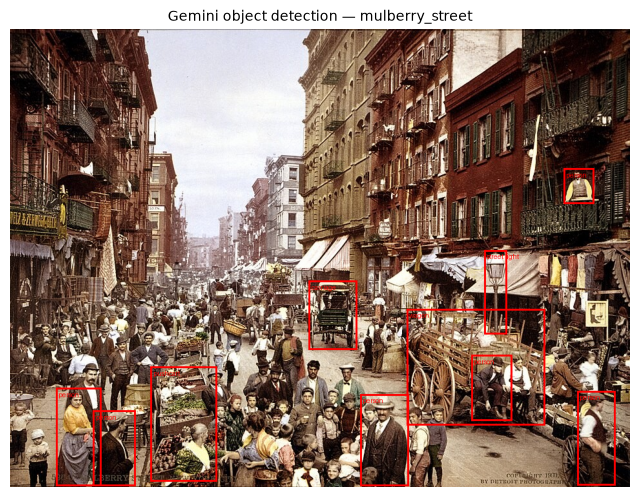

In [15]:
from PIL import ImageDraw

# Scale the 0-1000 normalized boxes back to pixel coordinates and draw them.
img = Image.open(io.BytesIO(images[DETECT_IMAGE_ID])).convert("RGB")
draw = ImageDraw.Draw(img)
width, height = img.size

for obj in detections.objects:
    ymin, xmin, ymax, xmax = obj.box_2d
    box = (xmin / 1000 * width, ymin / 1000 * height,
           xmax / 1000 * width, ymax / 1000 * height)
    draw.rectangle(box, outline="red", width=3)
    draw.text((box[0] + 4, box[1] + 4), obj.label, fill="red")

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"Gemini object detection — {DETECT_IMAGE_ID}", fontsize=10)
plt.axis("off")
plt.show()

**What just happened?** The model returned machine-checkable data: `response.parsed` is a real `Detections` object, Pydantic-validated against our schema, and the only post-processing we did was arithmetic (scaling 0–1000 coordinates to pixels — note the `[ymin, xmin, ymax, xmax]` order, a frequent source of flipped boxes). Detection boxes are approximate, and **your output may differ** from run to run — but the *shape* of the output never does, and that reliability is what makes it usable in a pipeline. Schema-constrained generation is a course-wide workhorse: the upcoming structured-outputs lesson makes it a first-class skill across all three providers.

## 8. Where Multimodal Retrieval Goes Next

Descriptions are the sturdy baseline, but they are no longer the only bridge across the modality gap. **Native multimodal embedding models** — Cohere's `embed-v4.0` and Google's multimodal embeddings among them (as of July 2026) — place images and text in the *same vector space directly*, so an image can be retrieved by a text query with no description step at all.

When does each win?

- **Descriptions** — controllable (you decide what gets indexed), debuggable (the index is human-readable text), and they work with *any* text embedding model, including everything already in our pipeline. Indexing costs one vision call per image.
- **Native multimodal embeddings** — no description step to maintain, and they can capture visual qualities that prose fumbles (texture, layout, style). The index, however, is opaque vectors, and you are tied to models that support image inputs.

Many production systems use both: native embeddings for recall, plus stored descriptions for reranking, filtering, and showing users *why* something matched.

📎 *The very next lesson is about choosing embedding models — Cohere's API included — so you'll meet the multimodal-capable generation of embedders up close.*

## 🔑 Key Takeaways

- Vision is now an ordinary API feature: all three course providers accept images as content parts, and one `generate_vision()` helper keeps the rest of the pipeline provider-neutral.
- The **describe → embed → search** pattern turns image retrieval into the text retrieval you already know — and makes **description quality the ceiling on retrieval quality**, so treat the describe prompt as seriously as any chunking decision.
- Answer from the **pixels**, retrieve by the **description**: summaries lose details, so the generation step should always get the primary source.
- Structured output + vision = data, not prose: Pydantic-validated `box_2d` detections you can draw, filter, and store — the difference between a demo and a pipeline component.
- Native multimodal embeddings (e.g. Cohere `embed-v4.0`, as of July 2026) remove the description step by embedding images directly; descriptions remain the more controllable, debuggable baseline.